
THREE-QUBIT GHZ CIRCUIT
          ┌───┐     ┌─┐      
q_0: ─────┤ X ├─────┤M├──────
          └─┬─┘┌───┐└╥┘┌─┐   
q_1: ───────┼──┤ X ├─╫─┤M├───
     ┌───┐  │  └─┬─┘ ║ └╥┘┌─┐
q_2: ┤ H ├──■────■───╫──╫─┤M├
     └───┘           ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 

GHZ STATE RESULTS
000 count : 602
P(000)   : 0.5017
001 count : 0
P(001)   : 0.0000
010 count : 0
P(010)   : 0.0000
011 count : 0
P(011)   : 0.0000
100 count : 0
P(100)   : 0.0000
101 count : 0
P(101)   : 0.0000
110 count : 0
P(110)   : 0.0000
111 count : 598
P(111)   : 0.4983


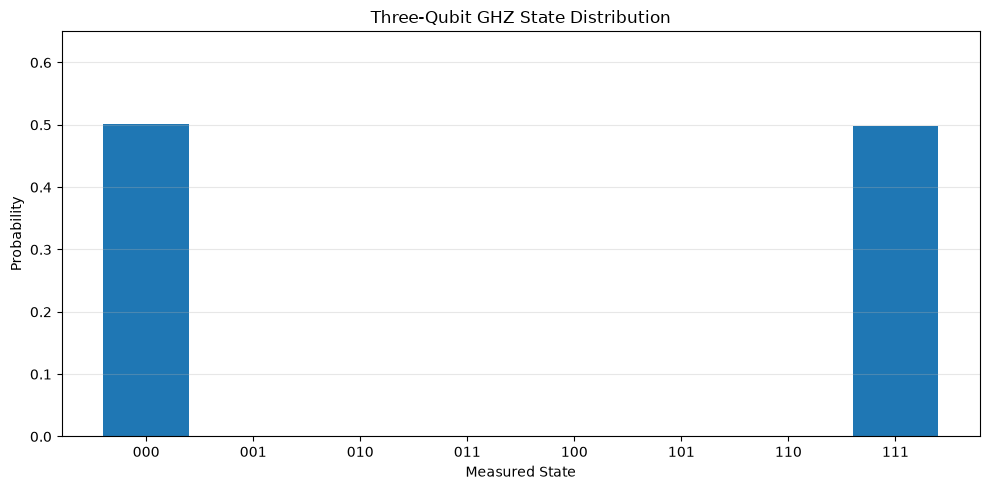

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

shots = 1200

qc = QuantumCircuit(3, 3)

qc.h(2)
qc.cx(2, 0)
qc.cx(2, 1)

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

print("\nTHREE-QUBIT GHZ CIRCUIT")
print("=" * 60)
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=shots).result()
counts = result.get_counts()

print("\nGHZ STATE RESULTS")
print("=" * 60)

states = ["000", "001", "010", "011", "100", "101", "110", "111"]

for state in states:
    count = counts.get(state, 0)
    probability = count / shots
    print(f"{state} count : {count}")
    print(f"P({state})   : {probability:.4f}")

probabilities = [counts.get(state, 0) / shots for state in states]

plt.figure(figsize=(10, 5))
plt.bar(states, probabilities)
plt.xlabel("Measured State")
plt.ylabel("Probability")
plt.title("Three-Qubit GHZ State Distribution")
plt.ylim(0, 0.65)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()